In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Veri yükleme
df = pd.read_csv('../data/cs-training.csv', index_col=0)

print("Veri boyutu:", df.shape)
print("\nİlk 5 satır:")
df.head()

Veri boyutu: (150000, 11)

İlk 5 satır:


,SeriousDlqin2yrs,RevolvingUtilizationOfUnsecuredLines,age,NumberOfTime30-59DaysPastDueNotWorse,DebtRatio,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,NumberOfTimes90DaysLate,NumberRealEstateLoansOrLines,NumberOfTime60-89DaysPastDueNotWorse,NumberOfDependents
1,1,0.766127,45,2,0.802982,9120.0,13,0,6,0,2.0
2,0,0.957151,40,0,0.121876,2600.0,4,0,0,0,1.0
3,0,0.658180,38,1,0.085113,3042.0,2,1,0,0,0.0
4,0,0.233810,30,0,0.036050,3300.0,5,0,0,0,0.0
5,0,0.907239,49,1,0.024926,63588.0,7,0,1,0,0.0


In [2]:
# Temel istatistikler
print("=== Hedef değişken dağılımı ===")
print(df['SeriousDlqin2yrs'].value_counts())
print(f"\nDefault oranı: {df['SeriousDlqin2yrs'].mean():.2%}")

print("\n=== Eksik değerler ===")
missing = df.isnull().sum()
missing_pct = (df.isnull().sum() / len(df)) * 100
missing_df = pd.DataFrame({'Eksik Sayı': missing, 'Yüzde': missing_pct})
print(missing_df[missing_df['Eksik Sayı'] > 0])

print("\n=== Temel istatistikler ===")
df.describe()

=== Hedef değişken dağılımı ===
SeriousDlqin2yrs
0    139974
1     10026
Name: count, dtype: int64

Default oranı: 6.68%

=== Eksik değerler ===
                    Eksik Sayı      Yüzde
MonthlyIncome            29731  19.820667
NumberOfDependents        3924   2.616000

=== Temel istatistikler ===


,SeriousDlqin2yrs,RevolvingUtilizationOfUnsecuredLines,age,NumberOfTime30-59DaysPastDueNotWorse,DebtRatio,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,NumberOfTimes90DaysLate,NumberRealEstateLoansOrLines,NumberOfTime60-89DaysPastDueNotWorse,NumberOfDependents
count,150000.000000,150000.000000,150000.000000,150000.000000,150000.000000,1.202690e+05,150000.000000,150000.000000,150000.000000,150000.000000,146076.000000
mean,0.066840,6.048438,52.295207,0.421033,353.005076,6.670221e+03,8.452760,0.265973,1.018240,0.240387,0.757222
std,0.249746,249.755371,14.771866,4.192781,2037.818523,1.438467e+04,5.145951,4.169304,1.129771,4.155179,1.115086
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,0.029867,41.000000,0.000000,0.175074,3.400000e+03,5.000000,0.000000,0.000000,0.000000,0.000000
50%,0.000000,0.154181,52.000000,0.000000,0.366508,5.400000e+03,8.000000,0.000000,1.000000,0.000000,0.000000
75%,0.000000,0.559046,63.000000,0.000000,0.868254,8.249000e+03,11.000000,0.000000,2.000000,0.000000,1.000000
max,1.000000,50708.000000,109.000000,98.000000,329664.000000,3.008750e+06,58.000000,98.000000,54.000000,98.000000,20.000000


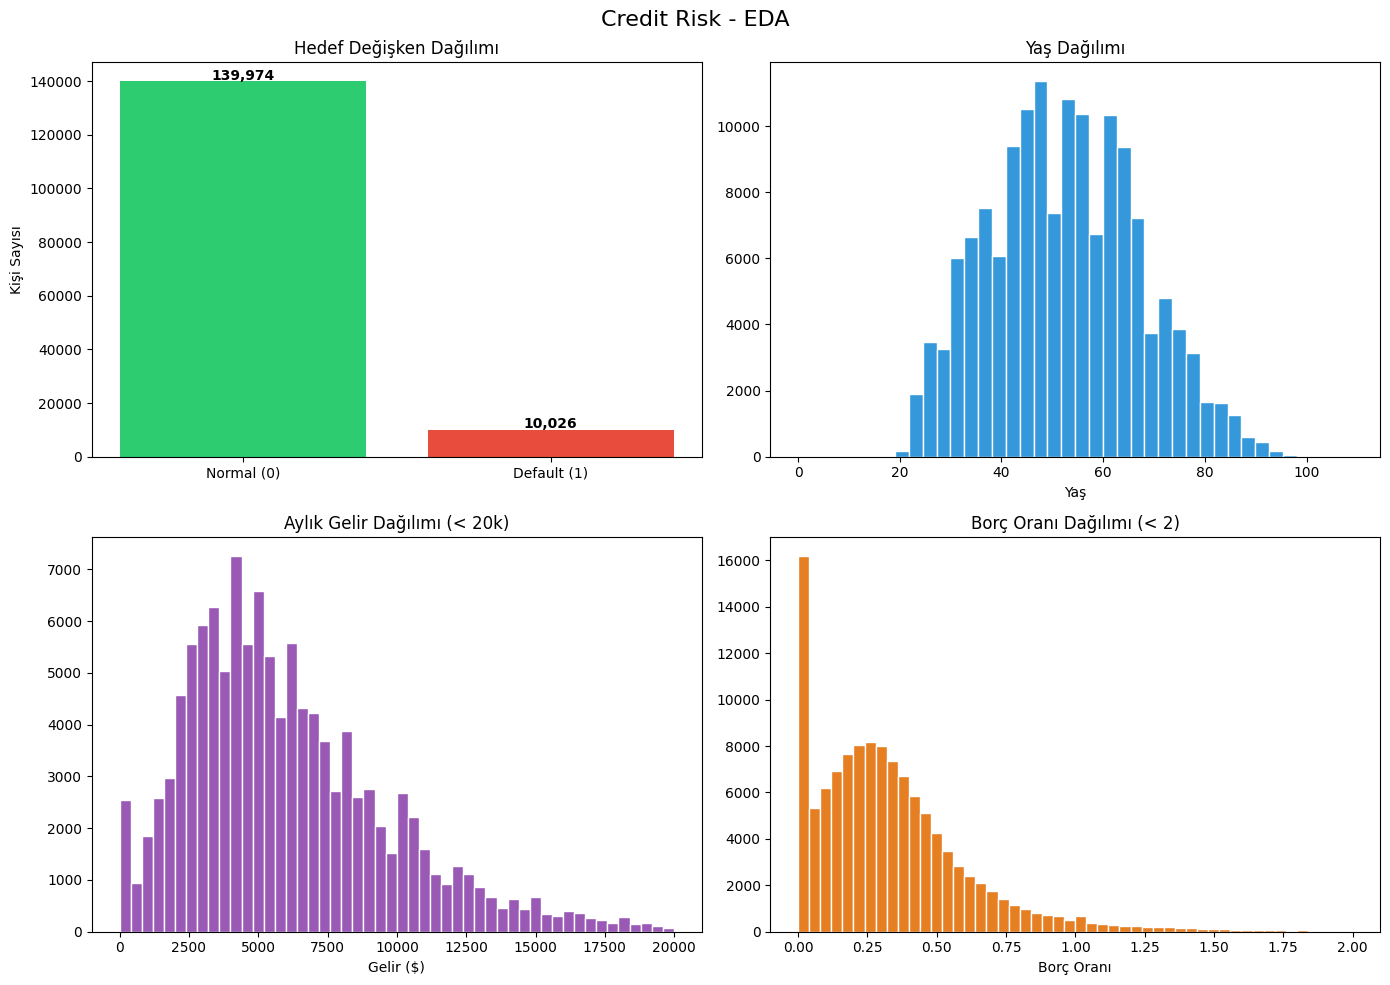

Grafik kaydedildi!


In [3]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Credit Risk - EDA', fontsize=16)

# 1. Hedef değişken dağılımı
axes[0,0].bar(['Normal (0)', 'Default (1)'], 
               df['SeriousDlqin2yrs'].value_counts().values,
               color=['#2ecc71', '#e74c3c'])
axes[0,0].set_title('Hedef Değişken Dağılımı')
axes[0,0].set_ylabel('Kişi Sayısı')
for i, v in enumerate(df['SeriousDlqin2yrs'].value_counts().values):
    axes[0,0].text(i, v + 500, f'{v:,}', ha='center', fontweight='bold')

# 2. Yaş dağılımı
axes[0,1].hist(df['age'].dropna(), bins=40, color='#3498db', edgecolor='white')
axes[0,1].set_title('Yaş Dağılımı')
axes[0,1].set_xlabel('Yaş')

# 3. Gelir dağılımı (outlier'ları kırp)
income_filtered = df['MonthlyIncome'].dropna()
income_filtered = income_filtered[income_filtered < 20000]
axes[1,0].hist(income_filtered, bins=50, color='#9b59b6', edgecolor='white')
axes[1,0].set_title('Aylık Gelir Dağılımı (< 20k)')
axes[1,0].set_xlabel('Gelir ($)')

# 4. Borç oranı dağılımı
debt_filtered = df['DebtRatio'][df['DebtRatio'] < 2]
axes[1,1].hist(debt_filtered, bins=50, color='#e67e22', edgecolor='white')
axes[1,1].set_title('Borç Oranı Dağılımı (< 2)')
axes[1,1].set_xlabel('Borç Oranı')

plt.tight_layout()
plt.savefig('../data/eda_plots.png', dpi=150, bbox_inches='tight')
plt.show()
print("Grafik kaydedildi!")